# Weld recognition & grinding path planning (PointNet) -- end-to-end

Single pipeline: raw `.ply` from the depth camera in, a grinding trajectory (position + normal + Euler angles per point, in the robot's calibrated coordinate frame) out. Combines, in order:
- `Point_Cloud_Preprocessing.ipynb` (surface reconstruction + outlier removal)
- PointNet segmentation (`old/Weld_Recognition&Grinding_Path_Planning(PointNet).ipynb`, the original author's own approach -- PointCNN is retired, see `old/`)
- the rest of that same notebook's path planning: voxel filter, B-spline surface fit + bead height, rasterize/skeletonize, path ordering, B-spline path fit, 3D projection, normals, eye-to-hand calibration, multi-layer offset, Euler-angle orientation

This is a straight combine-and-translate, not a rewrite -- algorithms and parameters are unchanged from the original notebooks. **Not included:** final export to robot-specific language (the original's TCP/RTCP RAPID `.mod` file generation cells) -- the pipeline stops at a robot-frame trajectory CSV.

**Needs `Pointnet_model_test11.h5`** in `PointNet_weight(Tensorflow)/` (deleted earlier in this project's cleanup, to be restored) to actually run the segmentation step -- everything before and after it can run independently.

In [1]:
import os
os.environ['CUDA_VISIBLE_DEVICES'] = '-1'  # TF's GPU path hits a JIT/ptxas compilation error on this machine (CUDA toolkit component mismatch); CPU inference works reliably and is fast enough (~7s for a full scan)
os.environ['TF_XLA_FLAGS'] = '--tf_xla_auto_jit=0'  # disable XLA auto-clustering
import tensorflow as tf
tf.config.optimizer.set_jit(False)
# TensorFlow must be imported and configured for CPU-only/no-JIT *before* Open3D --
# importing Open3D first initializes a CUDA context that makes TF attempt XLA JIT
# compilation later regardless of the flags above (fails: "libdevice not found").

2026-08-14 11:36:37.458849: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-08-14 11:36:37.458897: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-08-14 11:36:37.460824: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-08-14 11:36:37.471534: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-08-14 11:36:38.754633: W tensorflow/compiler/tf2

# Point cloud preprocessing

Unchanged from `Point_Cloud_Preprocessing.ipynb`: flip, then statistical outlier removal + Poisson surface reconstruction + uniform resampling + DBSCAN main-cluster extraction.

In [ ]:
import numpy as np
import os
os.environ.pop('WAYLAND_DISPLAY', None)  # Open3D's GLFW window fails to open under native Wayland on this machine (GLEW init error) -- force XWayland instead
os.environ['XDG_SESSION_TYPE'] = 'x11'
import open3d as o3d

def flip_point_cloud(point_cloud, axis='x'):
    if axis == 'x':
        rotation_matrix = np.array([[1,  0,  0],
                                    [0, -1,  0],
                                    [0,  0, -1]])
    elif axis == 'y':
        rotation_matrix = np.array([[-1,  0,  0],
                                    [0,  1,  0],
                                    [0,  0, -1]])
    elif axis == 'z':
        rotation_matrix = np.array([[-1,  0,  0],
                                    [0, -1,  0],
                                    [0,  0,  1]])
    pcd = o3d.geometry.PointCloud()
    pcd.points = o3d.utility.Vector3dVector(point_cloud)
    pcd.rotate(rotation_matrix)
    return np.asarray(pcd.points)

# Load the raw point cloud
# ply_file_path = 'C:/Users/mmdl/Desktop/tube_ply/1209_3.ply'  # original hardcoded path, kept for reference
ply_file_path = 'test_wen.ply'
pcd = o3d.io.read_point_cloud(ply_file_path)
point_cloud = np.asarray(pcd.points)

if pcd.has_colors():
    original_colors = np.asarray(pcd.colors)
else:
    original_colors = np.ones_like(point_cloud)

# Flip the point cloud
flipped_point_cloud = flip_point_cloud(point_cloud, axis='x')

pcd_original = o3d.geometry.PointCloud()
pcd_original.points = o3d.utility.Vector3dVector(point_cloud)
pcd_original.paint_uniform_color([0, 0, 1])  # original point cloud in blue

pcd_flipped = o3d.geometry.PointCloud()
pcd_flipped.points = o3d.utility.Vector3dVector(flipped_point_cloud)
pcd_flipped.colors = o3d.utility.Vector3dVector(original_colors)  # apply original colors to the flipped point cloud

# Blocking Open3D preview disabled -- see the single visualization cell at the end of the notebook.
# vis = o3d.visualization.Visualizer()
# vis.create_window()
# vis.add_geometry(pcd_flipped)
# vis.reset_view_point(True)  # fit the camera to the geometry -- without this the window can open pointed at empty space
# opt = vis.get_render_option()
# vis.run()
# vis.destroy_window()

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


In [3]:
from sklearn.cluster import DBSCAN

# Statistical outlier removal -- was disabled in the original notebook. Re-enabled: it removes a
# real floating noise cluster in test.ply (a depth-camera artifact, physically disconnected from the
# actual surface) that segmentation otherwise mislabels as weld bead.
pcd_flipped, ind = pcd_flipped.remove_statistical_outlier(nb_neighbors=20, std_ratio=2.0)

# Blocking Open3D preview disabled -- see the single visualization cell at the end of the notebook.
# o3d.visualization.draw_geometries([pcd_flipped], window_name="Point cloud after outlier removal",
#                                   width=800, height=600,
#                                   left=50, top=50,
#                                   point_show_normal=False, mesh_show_wireframe=False,
#                                   mesh_show_back_face=False)
# Estimate normals
pcd_flipped.estimate_normals(search_param=o3d.geometry.KDTreeSearchParamHybrid(radius=0.1, max_nn=30))

# Poisson surface reconstruction
mesh, densities = o3d.geometry.TriangleMesh.create_from_point_cloud_poisson(pcd_flipped, depth=8)

# Blocking Open3D preview disabled -- see the single visualization cell at the end of the notebook.
# o3d.visualization.draw_geometries([mesh], window_name="Poisson surface reconstruction",
#                                   width=800, height=600,
#                                   left=50, top=50,
#                                   point_show_normal=False, mesh_show_wireframe=True,
#                                   mesh_show_back_face=False)
# Filter out low-density mesh vertices
densities = np.asarray(densities)
vertices_to_remove = densities < np.quantile(densities, 0.07)
mesh.remove_vertices_by_mask(vertices_to_remove)

# Blocking Open3D preview disabled -- see the single visualization cell at the end of the notebook.
# o3d.visualization.draw_geometries([mesh], window_name="Surface after density filtering",
#                                   width=800, height=600,
#                                   left=50, top=50,
#                                   point_show_normal=False, mesh_show_wireframe=True,
#                                   mesh_show_back_face=False)
#-----------------------------------------------------------------------------------------------------------------------------

# Uniformly sample points from the reconstructed surface mesh
sampled_pcd = mesh.sample_points_uniformly(number_of_points=500000)
points = np.asarray(sampled_pcd.points)

# DBSCAN
dbscan = DBSCAN(eps=1, min_samples=50, algorithm='ball_tree')  # adjust eps and min_samples as needed
labels = dbscan.fit_predict(points)

unique_labels = set(labels)
# exclude the noise label (-1) from the running-choice unless every point is noise --
# max(..., key=count) alone can pick -1 as "main" when eps/min_samples are too tight
# for the actual point density, which silently keeps noise instead of the real surface
real_labels = unique_labels - {-1}
candidate_labels = real_labels if real_labels else unique_labels
main_cloud_label = max(candidate_labels, key=list(labels).count)  # find the label with the most points
main_points = points[labels == main_cloud_label]

main_pcd = o3d.geometry.PointCloud()
main_pcd.points = o3d.utility.Vector3dVector(main_points)

original_colors = np.asarray(sampled_pcd.colors)
main_colors = original_colors[labels == main_cloud_label]
main_pcd.colors = o3d.utility.Vector3dVector(main_colors)

# Blocking Open3D preview disabled -- see the single visualization cell at the end of the notebook.
# o3d.visualization.draw_geometries([main_pcd], window_name="Main point cloud",
#                                   width=800, height=600,
#                                   left=50, top=50,
#                                   point_show_normal=False, mesh_show_wireframe=False,
#                                   mesh_show_back_face=False)

os.makedirs('outputs', exist_ok=True)
preprocessed_ply_path = 'outputs/preprocessed.ply'
o3d.io.write_point_cloud(preprocessed_ply_path, main_pcd)
print(f'Wrote {preprocessed_ply_path}: {len(main_pcd.points)} points')

Wrote outputs/preprocessed.ply: 500000 points


# PointNet architecture

In [4]:
import sys
import time
import json
import random
import pandas as pd
from tqdm import tqdm
from glob import glob

import tensorflow as tf  # already configured for CPU/no-JIT in the setup cell at the top
import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt

from tensorflow.keras.layers import Input, Conv1D, BatchNormalization, Activation, GlobalMaxPooling1D, Dense, Reshape, Dot, MaxPooling1D, Concatenate
from tensorflow.keras.models import Model

In [5]:
from tensorflow.keras.models import load_model
from tensorflow.keras import regularizers

class OrthogonalRegularizer(keras.regularizers.Regularizer):
    """Reference: https://keras.io/examples/vision/pointnet/#build-a-model"""

    def __init__(self, num_features, l2reg_strength=0.001):
        self.num_features = num_features
        self.l2reg = l2reg_strength
        self.identity = tf.eye(num_features)

    def __call__(self, x):
        x = tf.reshape(x, (-1, self.num_features, self.num_features))
        xxt = tf.tensordot(x, x, axes=(2, 2))
        xxt = tf.reshape(xxt, (-1, self.num_features, self.num_features))
        return tf.reduce_sum(self.l2reg * tf.square(xxt - self.identity))

    def get_config(self):
        # super().get_config() isn't called since Regularizer's get_config doesn't return anything useful here
        config = {"num_features": self.num_features, "l2reg_strength": self.l2reg}
        return config

keras.utils.get_custom_objects().update({"OrthogonalRegularizer": OrthogonalRegularizer})
# surface: Pointnet_model_test11.h5   flat: Pointnet_model_test5.h5
ckpt_path = 'models/Pointnet_model_test11.h5'  # was 'C:/Users/mmdl/Desktop/Jiayuan/check_point/Pointnet_model_test11.h5'
Pointnet_model = load_model(ckpt_path, custom_objects={'OrthogonalRegularizer': OrthogonalRegularizer})

Pointnet_model.summary()

2026-08-14 11:37:26.393443: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:274] failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected
2026-08-14 11:37:26.393483: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:129] retrieving CUDA diagnostic information for host: tomas-Predator-PH317-52
2026-08-14 11:37:26.393495: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:136] hostname: tomas-Predator-PH317-52
2026-08-14 11:37:26.393621: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:159] libcuda reported version is: 580.173.2
2026-08-14 11:37:26.393662: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:163] kernel reported version is: 580.173.2
2026-08-14 11:37:26.393673: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:241] kernel version seems to match DSO: 580.173.2


Model: "functional_3"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_2 (InputLayer)        [(None, None, 3)]            0         []                            
                                                                                                  
 input_transformation_block  (None, None, 64)             256       ['input_2[0][0]']             
 _1_conv (Conv1D)                                                                                 
                                                                                                  
 input_transformation_block  (None, None, 64)             256       ['input_transformation_block_1
 _1_batch_norm (BatchNormal                                         _conv[0][0]']                 
 ization)                                                                              

# Load point cloud

In [6]:
time1 = time.time()

point_file = 'outputs/preprocessed.ply'  # output of the preprocessing step above
# point_file = 'D:/PartAnnotation/00000007/points/3.txt'  # original hardcoded path (labeled validation sample), kept for reference

if point_file.endswith('.ply'):
    pcd_in = o3d.io.read_point_cloud(point_file)
    point_cloud = np.asarray(pcd_in.points)
    truth_point = None
    truth_label = None
else:
    cloud = np.loadtxt(point_file)
    point_cloud = np.array(cloud[:, :3])
    truth_point = np.array(cloud[:, :3])
    truth_label = np.array(cloud[:, 3])

num_points = point_cloud.shape[0]

mean_point = np.mean(point_cloud, axis=0)
centered_cloud = point_cloud - mean_point

max_norm = np.max(np.linalg.norm(centered_cloud, axis=1))
point_cloud = centered_cloud / max_norm

print(f"Loaded {num_points} points from {point_file}")

Loaded 500000 points from outputs/preprocessed.ply


# PointNet segmentation

In [7]:
n_points = 2048
n_batches = num_points // n_points
all_point_clouds = []
all_predictions = []
all_labels = []
all_truth_labels = [] if truth_label is not None else None

for _ in range(n_batches):
    # If the point cloud has more than n_points points, randomly pick n_points of them
    if point_cloud.shape[0] > n_points:
        idx = np.random.choice(point_cloud.shape[0], n_points, replace=False)
        point_cloud_sampled = point_cloud[idx, :]
        truth_sampled = truth_point[idx, :] if truth_point is not None else None
        truth_label_sampled = truth_label[idx] if truth_label is not None else None
    else:
        # If the point cloud has fewer than n_points points, zero-pad it
        padding = np.zeros((n_points - point_cloud.shape[0], point_cloud.shape[1]))
        point_cloud_sampled = np.vstack((point_cloud, padding))
        truth_sampled = None
        truth_label_sampled = None

    point_cloud_batch = point_cloud_sampled.reshape(1, n_points, 3)

    predictions = Pointnet_model.predict(point_cloud_batch)
    labels = np.argmax(predictions, axis=2).flatten()

    all_point_clouds.append(point_cloud_sampled)
    all_predictions.append(predictions.reshape(n_points, -1))
    all_labels.append(labels)
    if all_truth_labels is not None:
        all_truth_labels.append(truth_label_sampled)

all_point_clouds = np.array(all_point_clouds).reshape(-1, 3)
all_predictions = np.array(all_predictions).reshape(-1, predictions.shape[-1])
all_labels = np.array(all_labels).reshape(-1)

print("Point clouds shape:", all_point_clouds.shape)
print("Predictions shape:", all_predictions.shape)
print("Labels shape:", all_labels.shape)

if all_truth_labels is not None:
    all_truth_labels = np.array(all_truth_labels).reshape(-1)
    correct_predictions = np.sum(all_labels == all_truth_labels)
    accuracy = correct_predictions / all_labels.shape[0]
    print(f"Correctly classified points: {correct_predictions}")
    print(f"Total points: {all_labels.shape[0]}")
    print(f"Classification accuracy: {accuracy:.4f}")

time2 = time.time()
t1 = np.round((time2 - time1), 4)

print("Weld bead recognition time: ", t1, "s")

1/1 [==============================] - 0s 73ms/step
Point clouds shape: (499712, 3)
Predictions shape: (499712, 3)
Labels shape: (499712,)
Weld bead recognition time:  41.5797 s


# View segmentation results

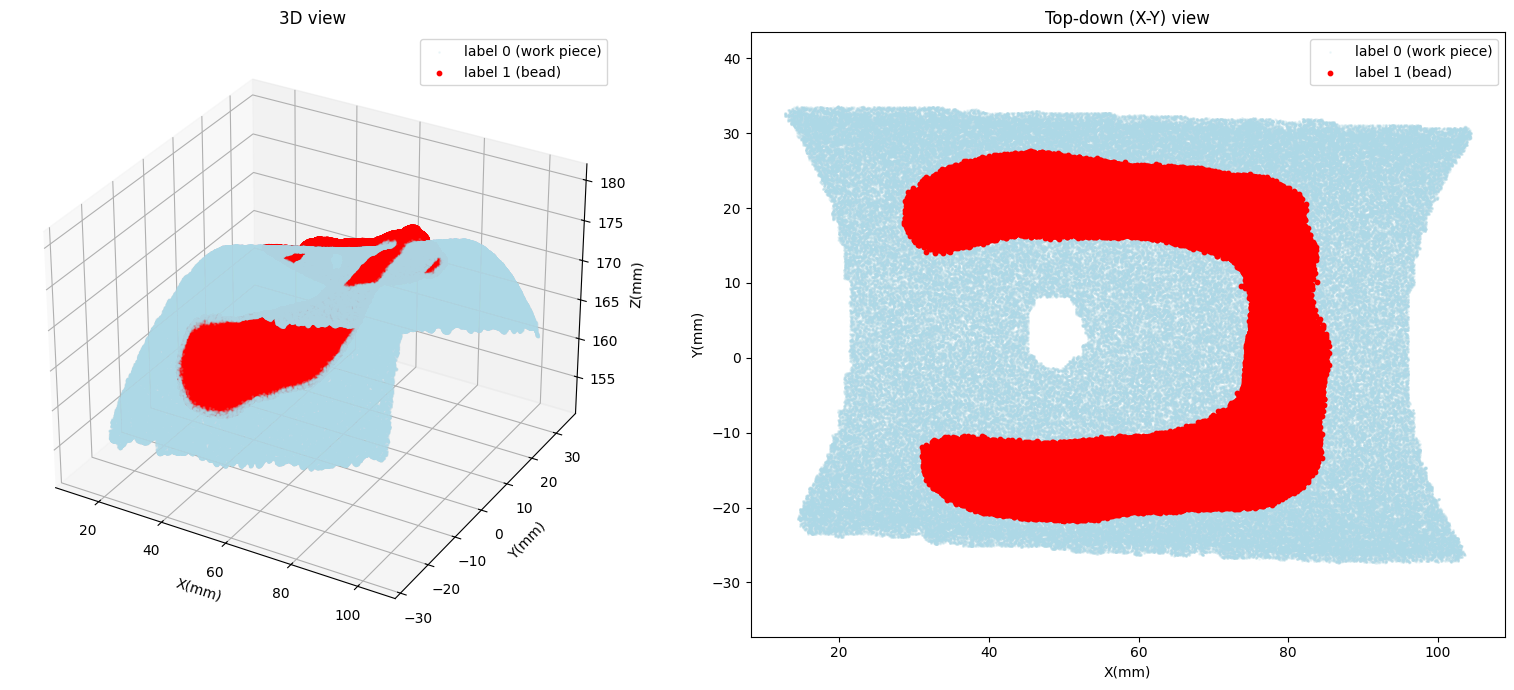

In [8]:
centered_cloud = all_point_clouds * max_norm
all_point_clouds = centered_cloud + mean_point

point_cloud = point_cloud.reshape(-1, 3)

points_label0 = all_point_clouds[all_labels == 0]
points_label1 = all_point_clouds[all_labels == 1]

if truth_label is not None:
    truth_points_label0 = truth_sampled[truth_label_sampled == 0]
    truth_points_label1 = truth_sampled[truth_label_sampled == 1]

pcd_label0 = o3d.geometry.PointCloud()
pcd_label0.points = o3d.utility.Vector3dVector(points_label0[:])
pcd_label0.paint_uniform_color([0, 0, 1])  # blue

pcd_label1 = o3d.geometry.PointCloud()
pcd_label1.points = o3d.utility.Vector3dVector(points_label1[:])
pcd_label1.paint_uniform_color([1, 0, 0])  # red

# Blocking Open3D preview disabled -- see the single visualization cell at the end of the notebook.
# combined_pcd = pcd_label0 + pcd_label1
# vis = o3d.visualization.Visualizer()
# vis.create_window()
# vis.add_geometry(combined_pcd)
# axis = o3d.geometry.TriangleMesh.create_coordinate_frame(size=10)
# view_ctl = vis.get_view_control()
# view_ctl.set_up([0, 0, 1])
# view_ctl.set_lookat([0, 0, 0])
# view_ctl.set_front([1, 1, 1])
# vis.run()
# vis.destroy_window()

fig = plt.figure(figsize=(16, 7))
ax1 = fig.add_subplot(121, projection='3d')
ax1.scatter(points_label0[:,0], points_label0[:,1], points_label0[:,2], c='lightblue', s=1, alpha=0.15, label='label 0 (work piece)')
ax1.scatter(points_label1[:,0], points_label1[:,1], points_label1[:,2], c='red', s=10, label='label 1 (bead)')
ax1.set_xlabel('X(mm)'); ax1.set_ylabel('Y(mm)'); ax1.set_zlabel('Z(mm)')
ax1.set_title('3D view'); ax1.legend()
ax2 = fig.add_subplot(122)
ax2.scatter(points_label0[:,0], points_label0[:,1], c='lightblue', s=1, alpha=0.15, label='label 0 (work piece)')
ax2.scatter(points_label1[:,0], points_label1[:,1], c='red', s=10, label='label 1 (bead)')
ax2.set_xlabel('X(mm)'); ax2.set_ylabel('Y(mm)')
ax2.set_title('Top-down (X-Y) view'); ax2.axis('equal'); ax2.legend()
plt.tight_layout()
plt.show()

# Voxel filter the work-piece surface

Voxel size = 1.5
Voxel size = 2
1675 points in total.


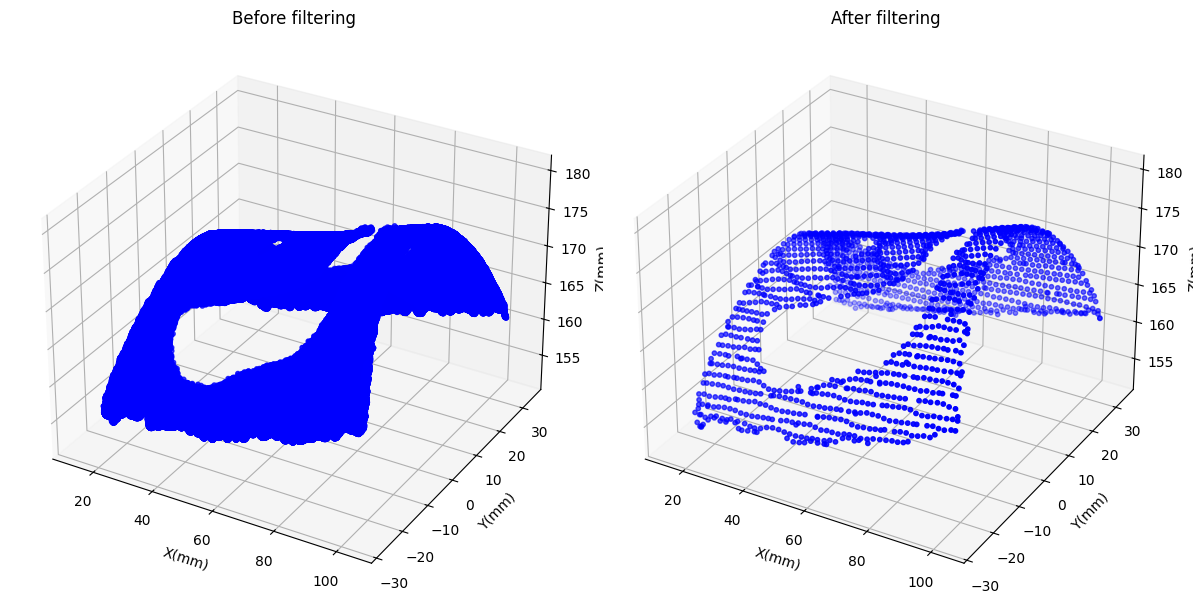

Voxel filtering time:  22.714 s


In [9]:
from mpl_toolkits.mplot3d import Axes3D
import scipy.ndimage as ndimage

time3 = time.time()

#points_label1 = largest_cluster_points
weld_bead = points_label1
work_piece = points_label0

fig = plt.figure(figsize=(12, 6))
ax1 = fig.add_subplot(1, 2, 1, projection='3d')
ax1.set_xlabel("X(mm)")
ax1.set_ylabel("Y(mm)")
ax1.set_zlabel("Z(mm)")
ax1.set_title("Before filtering")
ax1.scatter(work_piece[:, 0], work_piece[:, 1], work_piece[:, 2],
            c='blue', s=10)

# Get the min/max of x, y, z
x_min, x_max = np.min(work_piece[:, 0]), np.max(work_piece[:, 0])
y_min, y_max = np.min(work_piece[:, 1]), np.max(work_piece[:, 1])
z_min, z_max = np.min(work_piece[:, 2]), np.max(work_piece[:, 2])

size_v = 1.5  # voxel size
print("Voxel size =", size_v)

filtered_points = []
tempx = []
tempy = []
tempz = []
for i in range(0, len(work_piece)):
    tempx.append(work_piece[i][0])       # collect the x values of each point
    tempy.append(work_piece[i][1])       # collect the y values of each point
    tempz.append(work_piece[i][2])       # collect the z values of each point

x_max = np.max(tempx)               # min/max of x, y, z
y_max = np.max(tempy)
z_max = np.max(tempz)
x_min = np.min(tempx)
y_min = np.min(tempy)
z_min = np.min(tempz)

size_v = 2  # 5
print("Voxel size =", str(size_v))

d_x = (x_max-x_min)/size_v    # number of voxels needed to cover the whole range, e.g. max=10 min=0 voxel size=1 -> (10-0)/1=10 voxels
d_y = (y_max-y_min)/size_v
d_z = (z_max-z_min)/size_v

h = []  # stores the voxel index (linear) for each point
for i in range(0, len(work_piece)):
    hx = np.floor((work_piece[i][0] - x_min) / size_v)   # floor -> project onto the X grid; subtract min to get the voxel index
    hy = np.floor((work_piece[i][1] - y_min) / size_v)   # project onto the Y grid
    hz = np.floor((work_piece[i][2] - z_min) / size_v)   # project onto the Z grid
    h.append(hx + hy*d_x + hz*d_x*d_y)              # ****  linear index

h = np.array(h)
index_h = np.argsort(h)   # sort the h array
h_sorted = h[index_h]     # store the sorted elements in h_sorted
count = 0
np.seterr(divide='ignore', invalid='ignore')  # skip warnings, e.g. division by zero

for i in range(0, len(h_sorted)-1):
    if h_sorted[i] == h_sorted[i+1]:       # same voxel -> skip, move to the next iteration
        continue
    index_point = index_h[count:i+1]
    x_temp = []
    y_temp = []
    z_temp = []
    for p in index_point:
        x_temp.append(work_piece[p][0])
        y_temp.append(work_piece[p][1])
        z_temp.append(work_piece[p][2])
    filtered_points.append([np.mean(x_temp), np.mean(y_temp), np.mean(z_temp)])   # average x, y, z to get the centroid
    count = i

filtered_points = np.array(filtered_points, dtype=np.float64)
x_f = []
y_f = []
z_f = []
for i in range(0, len(filtered_points)):
    x_f.append(filtered_points[i][0])
    y_f.append(filtered_points[i][1])
    z_f.append(filtered_points[i][2])

while (0 in x_f):                  # remove the values that just became 0
    x_f.remove(0)
    y_f.remove(0)
    z_f.remove(0)

print(str(len(x_f)), "points in total.")

work_piece = np.array(list(zip(x_f, y_f, z_f)))
point_cloud_o3d = o3d.geometry.PointCloud()
point_cloud_o3d.points = o3d.utility.Vector3dVector(work_piece)

# Statistical outlier removal
cl, ind = point_cloud_o3d.remove_statistical_outlier(nb_neighbors=5, std_ratio=1.5)
work_piece = np.asarray(cl.points)

ax2 = fig.add_subplot(1, 2, 2, projection='3d')
ax2.set_xlabel("X(mm)")
ax2.set_ylabel("Y(mm)")
ax2.set_zlabel("Z(mm)")
ax2.set_title("After filtering")
ax2.scatter(work_piece[:, 0], work_piece[:, 1], work_piece[:, 2],  c='blue', s=10)
plt.tight_layout()
plt.show()

time4 = time.time()
t2 = np.round((time4 - time3), 4)

print("Voxel filtering time: ", t2, "s")

# Surface fit + weld bead height

Weld bead height: 2.871 mm


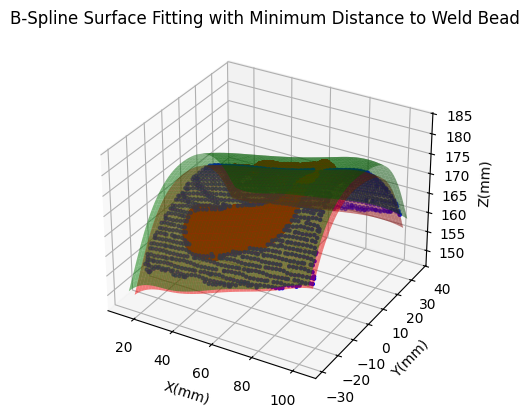

Weld bead height computation time:  58.0073 s


In [10]:
from scipy.interpolate import SmoothBivariateSpline
from scipy.spatial import KDTree

time5 = time.time()

x = work_piece[:, 0]
y = work_piece[:, 1]
z = work_piece[:, 2]

#-------------------------------------------------------------------------------------------------------------------

x_min, x_max = x.min(), x.max()
y_min, y_max = y.min(), y.max()
spline = SmoothBivariateSpline(x, y, z, s = 50)  # bivariate spline surface fit

# Build a grid to evaluate the surface on
X, Y = np.meshgrid(np.linspace(x_min, x_max, 300), np.linspace(y_min, y_max, 300))
Z = spline.ev(X.ravel(), Y.ravel()).reshape(300, 300)

dZ_dx = spline.ev(X.ravel(), Y.ravel(), dx=1, dy=0).reshape(300, 300)  # surface normal via partial derivatives
dZ_dy = spline.ev(X.ravel(), Y.ravel(), dx=0, dy=1).reshape(300, 300)
normals = np.dstack((-dZ_dx, -dZ_dy, np.ones_like(Z)))
normals /= np.linalg.norm(normals, axis=2, keepdims=True)  # normalize the normal vectors
weld_bead_tree = KDTree(weld_bead)

# Set the offset step size and stopping condition
offset_distance = 0.05  # distance per offset step
max_offset = 100       # maximum offset distance (avoids an infinite loop)
current_offset = 1    # offset the surface and check for collisions
last_offset_point = []

while current_offset < max_offset:
    Z_offset = Z + current_offset * normals[..., 2]  # compute the offset Z values from the normal vectors
    X_offset = X + current_offset * normals[..., 0]
    Y_offset = Y + current_offset * normals[..., 1]

    surface_points = np.column_stack((X_offset.ravel(), Y_offset.ravel(), Z_offset.ravel())) # each offset point's minimum distance to the weld bead
    dist, _ = weld_bead_tree.query(surface_points)

    if np.all(dist > offset_distance):   # check whether every point has cleared the weld_bead point cloud
        break

    last_offset_point = surface_points[dist <= offset_distance]
    current_offset += offset_distance

original_points = np.column_stack((X.ravel(), Y.ravel(), Z.ravel()))  # shortest distance from the original surface to the final offset surface
offset_points = np.column_stack((X_offset.ravel(), Y_offset.ravel(), Z_offset.ravel()))
original_tree = KDTree(original_points)

# Find the closest point pair
if len(last_offset_point) > 0:
    last_offset_point = np.array(last_offset_point)
    weld_bead_distances, nearest_indices = weld_bead_tree.query(last_offset_point)
    closest_weld_bead_points = weld_bead[nearest_indices]
    closest_original_distances, closest_original_indices = original_tree.query(closest_weld_bead_points)

    min_distance = np.round(closest_original_distances.min(), 3)
    print("Weld bead height:", min_distance, "mm")

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(x, y, z, c='blue', s=5)  # original surface
ax.scatter(weld_bead[:, 0], weld_bead[:, 1], weld_bead[:, 2], c='red', s=5)  # weld bead points
ax.plot_surface(X, Y, Z, color='r', alpha=0.5)  # original surface
ax.plot_surface(X_offset, Y_offset, Z_offset, color='g', alpha=0.5)  # offset surface
ax.set_xlabel('X(mm)')
ax.set_ylabel('Y(mm)')
ax.set_zlabel('Z(mm)')
plt.title('B-Spline Surface Fitting with Minimum Distance to Weld Bead')
plt.show()

time6 = time.time()
t3 = np.round((time6 - time5), 4)

print("Weld bead height computation time: ", t3, "s")

In [11]:
from scipy.spatial import Delaunay
pcd = o3d.geometry.PointCloud()
pcd.points = o3d.utility.Vector3dVector(work_piece)

# Build a triangle mesh over the fitted surface
vertices = np.column_stack((X.ravel(), Y.ravel(), Z.ravel()))
tri = Delaunay(vertices[:, :2])
triangles = tri.simplices

# Point cloud rasterization and skeletonization

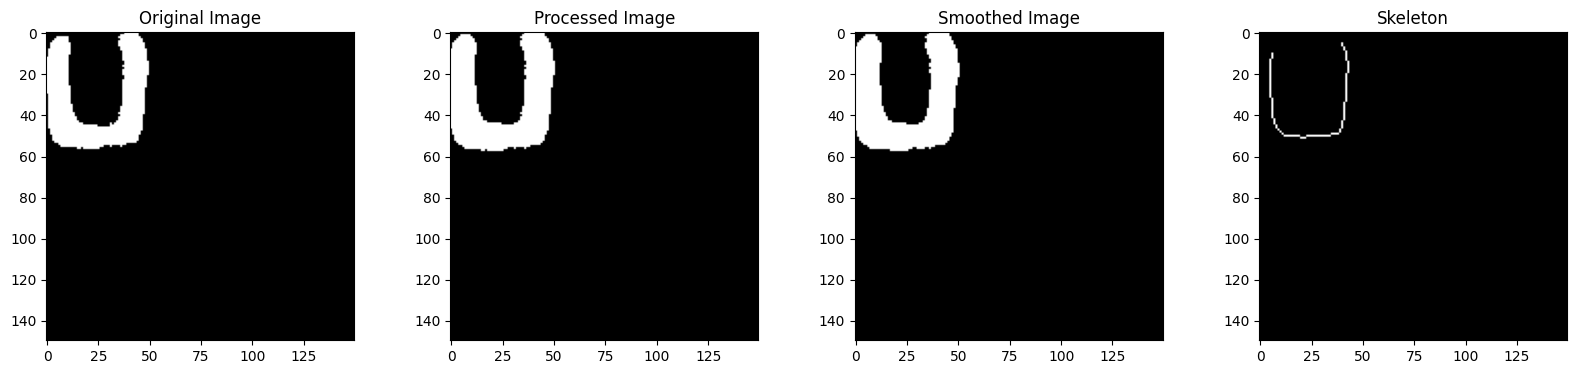

Point cloud rasterization time:  0.9559 s


In [12]:
from skimage.morphology import skeletonize, dilation, erosion, disk, opening, convex_hull_image
from skimage.filters import gaussian
import skimage
import cv2

time7 = time.time()

# Create a blank (150, 150) image
image = np.zeros((150, 150), dtype=np.uint8)

# Map the point cloud into the image range
x_mapped = np.clip(((weld_bead[:, 0] - min(weld_bead[:, 0]))).astype(int), 0, image.shape[0] - 1)
y_mapped = np.clip(((weld_bead[:, 1] - min(weld_bead[:, 1]))).astype(int), 0, image.shape[1] - 1)

# Set the mapped points to 255 in the image
image[x_mapped, y_mapped] = 255

selem1 = disk(1)
selem2 = disk(2)
ero_image = erosion(image, selem1)
ero_image = dilation(ero_image, selem1)
ero_image = erosion(ero_image, selem1)
ero_image = dilation(ero_image, selem1)
ero_image = erosion(ero_image, selem1)
ero_image = dilation(ero_image, selem2)
# ero_image = erosion(ero_image, selem2)

# Find contours
contours, _ = cv2.findContours(ero_image, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)

# Create a blank image to hold the result
smoothed_image = np.zeros_like(ero_image)

# epsilon ratio -- tune this to adjust the smoothing strength
epsilon_ratio = 0.003

# Walk all contours and smooth them
for contour in contours:
    epsilon = epsilon_ratio * cv2.arcLength(contour, True)
    approx = cv2.approxPolyDP(contour, epsilon, True)
    cv2.drawContours(smoothed_image, [approx], -1, (255), thickness=cv2.FILLED)

# Smooth the contour with an opening operation
opened_image = opening(smoothed_image, selem1)

# Skeletonize
skeleton = skeletonize(opened_image, method='lee')

fig, axes = plt.subplots(1, 4, figsize=(20, 4), sharex=True)
ax = axes.ravel()

ax[0].imshow(image, cmap=plt.cm.gray)
ax[0].set_title('Original Image')

ax[1].imshow(ero_image, cmap=plt.cm.gray)
ax[1].set_title('Processed Image')

ax[2].imshow(smoothed_image, cmap=plt.cm.gray)
ax[2].set_title('Smoothed Image')

ax[3].imshow(skeleton, cmap=plt.cm.gray)
ax[3].set_title('Skeleton')
plt.show()

time8 = time.time()
t4 = np.round((time8 - time7), 4)

print("Point cloud rasterization time: ", t4, "s")

# Convert skeleton pixels to a point cloud

Skeleton point cloud shape: (111, 2)


<function matplotlib.pyplot.show(close=None, block=None)>

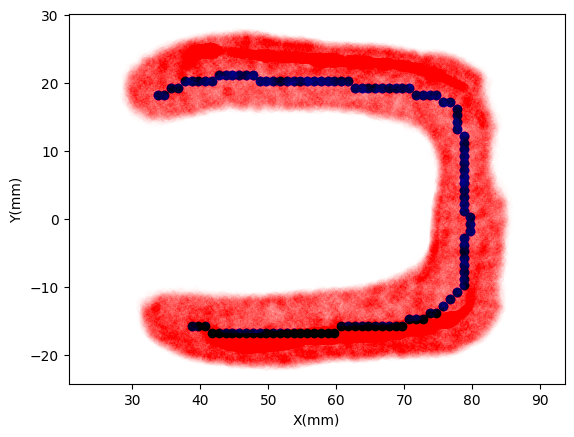

In [13]:
from scipy.spatial import distance

time9 = time.time()

skeleton_points = []
for y in range(skeleton.shape[0]):
    for x in range(skeleton.shape[1]):
        # if the pixel is nonzero, add its coordinates to the point data
        if skeleton[y, x]:
            skeleton_points.append([x, y])

skeleton_points = np.array(skeleton_points)
print("Skeleton point cloud shape:", skeleton_points.shape)

x_set = min(weld_bead[:, 0]) - min(image[:, 0])
y_set = min(weld_bead[:, 1]) - min(image[:, 1])
x_path = skeleton_points[:, 1] + x_set
y_path = skeleton_points[:, 0] + y_set

path_2D = []
for i in range(len(x_path)):
    path_2D.append([x_path[i], y_path[i]])

plt.scatter(x_path, y_path, c = 'blue', label = 'Path points(Skeleton)')
plt.scatter(weld_bead[:, 0], weld_bead[:, 1], c = 'red', alpha = 0.003, label = 'Weld bead')
plt.axis('equal')
plt.xlabel('X(mm)')
plt.ylabel('Y(mm)')
plt.show

# Path point ordering algorithm

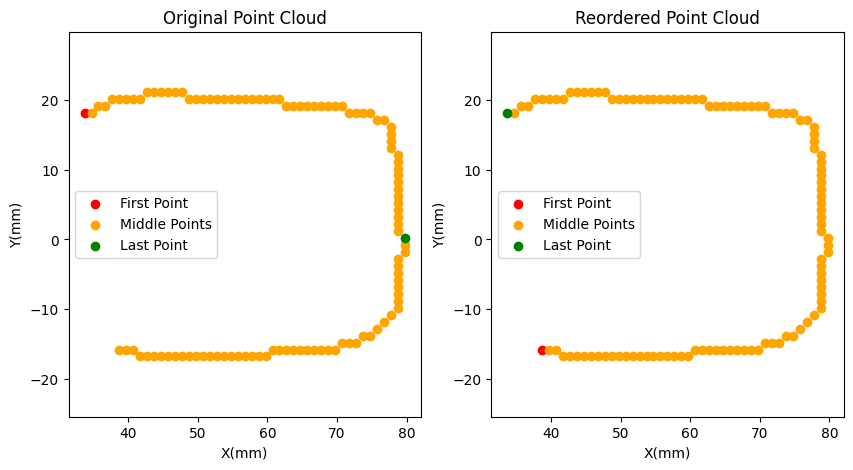

Path point ordering time:  2.1613 s


In [14]:
from scipy.spatial import distance_matrix

points = np.array(path_2D)
def calculate_total_distance(points, order):
    distances = distance_matrix(points[order], points[order])
    total_distance = sum(distances[i, i+1] for i in range(len(order) - 1))
    return total_distance

def reorder_weld_bead(points, start_index):
    num_points = len(points)
    distances = distance_matrix(points, points)
    reordered_indices = [start_index]  # Start with the given start point
    remaining_indices = set(range(num_points))  # Indices of points not yet reordered
    remaining_indices.remove(start_index)

    while remaining_indices:
        last_index = reordered_indices[-1]
        nearest_index = min(remaining_indices, key=lambda x: distances[last_index, x])
        reordered_indices.append(nearest_index)
        remaining_indices.remove(nearest_index)

    return reordered_indices

# Initialize the minimum distance
min_total_distance = float('inf')
best_order = None

# Try every point as the start point
for i in range(len(points)):
    current_order = reorder_weld_bead(points, i)
    current_distance = calculate_total_distance(points, current_order)

    if current_distance < min_total_distance:
        min_total_distance = current_distance
        best_order = current_order

# Reorder the points using the best ordering found
reordered_points = points[best_order]

plt.figure(figsize=(10, 5))
plt.subplot(121)
plt.scatter(points[0, 0], points[0, 1], c='red', label='First Point')
plt.scatter(points[1:-1, 0], points[1:-1, 1], c='orange', alpha=1, label='Middle Points')
plt.scatter(points[-1, 0], points[-1, 1], c='green', label='Last Point')
plt.title('Original Point Cloud')
plt.axis('equal')
plt.xlabel('X(mm)')
plt.ylabel('Y(mm)')
plt.legend()

plt.subplot(122)
plt.scatter(reordered_points[0, 0], reordered_points[0, 1], c='red', label='First Point')
plt.scatter(reordered_points[1:-1, 0], reordered_points[1:-1, 1], c='orange', alpha=1, label='Middle Points')
plt.scatter(reordered_points[-1, 0], reordered_points[-1, 1], c='green', label='Last Point')
plt.title('Reordered Point Cloud')
plt.axis('equal')
plt.xlabel('X(mm)')
plt.ylabel('Y(mm)')
plt.legend()
plt.show()
path_2D = reordered_points.astype(int)

from scipy.ndimage import gaussian_filter1d

# Gaussian smoothing
def smooth_path(path, dimension, sigma):
    smoothed_path = np.zeros_like(path)
    for i in range(dimension):
        smoothed_path[:, i] = gaussian_filter1d(path[:, i], sigma=sigma)
    return smoothed_path

time10 = time.time()
t5 = np.round((time10 - time9), 4)

print("Path point ordering time: ", t5, "s")

# B-spline curve fitting + Douglas-Peucker algorithm

num_samples:  1415


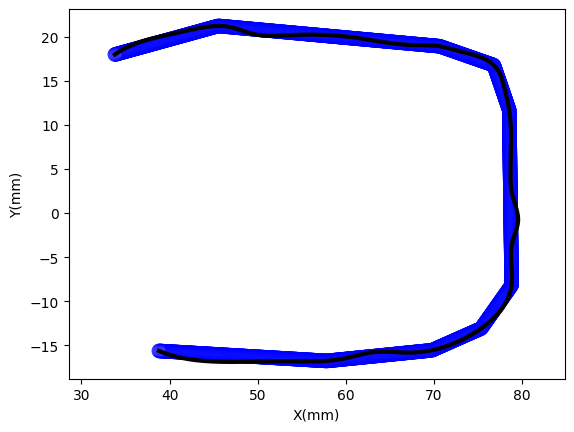

angle_init:  -3.4105
Path fitting and simplification time:  0.5523 s


In [15]:
import scipy.interpolate as si
import math

time11 = time.time()

tck, u = si.splprep(reordered_points.T, s=5, k=3) #s=5
u = np.linspace(0, 1, 200)
# B-spline curve fitting
t = np.linspace(0, 1, len(reordered_points) - 2, endpoint=True)
t = np.pad(t, (3, 3), mode='constant', constant_values=(0, 1))
spline_points = np.array(si.splev(u, tck)).T

# Douglas-Peucker algorithm
def douglas_peucker(points, epsilon):
    def perpendicular_distance(point, start, end):
        if np.array_equal(start, end):
            return np.linalg.norm(point - start)
        return np.abs(np.cross(end - start, start - point)) / np.linalg.norm(end - start)

    dmax = 0.0
    index = 0
    end = len(points)
    for i in range(1, end - 1):
        d = perpendicular_distance(points[i], points[0], points[-1])
        if d > dmax:
            index = i
            dmax = d
    if dmax > epsilon:
        rec_results1 = douglas_peucker(points[:index + 1], epsilon)
        rec_results2 = douglas_peucker(points[index:], epsilon)
        return np.vstack((rec_results1[:-1], rec_results2))
    else:
        return np.array([points[0], points[-1]])

epsilon = 1  #1.75
simplified_points = douglas_peucker(spline_points, epsilon)

def uniform_sampling(points, num_samples):
    cumulative_lengths = np.cumsum(np.r_[0, np.sqrt(np.sum(np.diff(points, axis=0) ** 2, axis=1))])
    uniform_samples = np.linspace(0, cumulative_lengths[-1], num_samples)
    return np.vstack([np.interp(uniform_samples, cumulative_lengths, points[:, i]) for i in range(points.shape[1])]).T

num_samples = math.ceil(min_total_distance*12)  # number of path sample points needed

sampled_points = uniform_sampling(simplified_points, num_samples)
print("num_samples: ", num_samples)

def extrapolate_points_3d(sampled_points, num_extrapolate, num_reference=30):
    num_extrapolate += 1  # extra layer to include the extrapolated point

    # Make sure the reference point count doesn't exceed the point set length
    num_reference = min(num_reference, len(sampled_points) - 1)

    # Compute the trend vector at the start (average of the nearest num_reference points)
    start_directions = np.diff(sampled_points[:num_reference + 1], axis=0)
    start_vector = np.mean(start_directions, axis=0)

    # Compute the trend vector at the end (average of the nearest num_reference points)
    end_directions = np.diff(sampled_points[-(num_reference + 1):], axis=0)
    end_vector = np.mean(end_directions, axis=0)

    # Extrapolate along the trend vector
    start_extrapolated_points = [sampled_points[0] - i * start_vector for i in range(1, num_extrapolate + 1)]
    end_extrapolated_points = [sampled_points[-1] + i * end_vector for i in range(1, num_extrapolate + 1)]

    # Merge the extrapolated points with the original points
    new_points = np.vstack(start_extrapolated_points[::-1] + [sampled_points] + end_extrapolated_points)
    return new_points

sampled_points = np.array(extrapolate_points_3d(sampled_points, 0))  # how many path points to extrapolate, 55

def calculate_angle_difference(points_2d):
    points_2d = np.array(points_2d, dtype=float)

    if points_2d.shape[1] != 2:
        raise ValueError("points_2d must be a 2D numpy array with 2 columns representing 2D coordinates.")

    def angle_between(v1, v2):
        """Calculate the angle between two vectors and determine the direction of rotation."""
        dot_product = np.dot(v1, v2)
        norm_v1 = np.linalg.norm(v1)
        norm_v2 = np.linalg.norm(v2)

        cos_theta = dot_product / (norm_v1 * norm_v2)
        angle = np.arccos(np.clip(cos_theta, -1.0, 1.0))  # Clamp cos_theta to avoid numerical issues

        cross_product = v1[0] * v2[1] - v1[1] * v2[0]
        if cross_product < 0:
            angle = -angle

        return np.degrees(angle)

    angle_differences = []
    for i in range(1, len(points_2d)):
        vector_prev = points_2d[i - 1] - points_2d[i - 2] if i > 1 else points_2d[i] - points_2d[i - 1]
        vector_curr = points_2d[i] - points_2d[i - 1]

        angle = angle_between(vector_prev, vector_curr)
        angle_differences.append(angle)

    return angle_differences

angle_diffs = calculate_angle_difference(sampled_points)
angle_diffs = np.round(angle_diffs, 4)

sampled_points = sampled_points[1:-1, :]
angle_diffs = angle_diffs[:-1]

plt.plot(spline_points[:, 0], spline_points[:, 1], color='black', label='B-spline', lw=3)
plt.scatter(sampled_points[:, 0], sampled_points[:, 1],
            facecolors='none', edgecolors='blue', s=100, lw=0.5, alpha=1, label='Sampled Points')
plt.axis('equal')
plt.xlabel('X(mm)')
plt.ylabel('Y(mm)')
plt.show()

def vector_from_a_to_b(a, b):
    a = np.array(a, dtype=float)
    b = np.array(b, dtype=float)
    vector = b - a
    return vector

def angle_with_reference(vector, reference_vector):
    vector = np.array(vector, dtype=float)
    reference_vector = np.array(reference_vector, dtype=float)

    dot_product = np.dot(vector, reference_vector)
    norm_vector = np.linalg.norm(vector)
    norm_reference_vector = np.linalg.norm(reference_vector)
    cos_theta = dot_product / (norm_vector * norm_reference_vector)
    angle = np.arccos(np.clip(cos_theta, -1.0, 1.0))
    cross_product = np.cross(np.append(reference_vector, 0), np.append(vector, 0))

    if cross_product[2] < 0:
        angle = -angle

    return np.degrees(angle)

a = [sampled_points[0, 0], sampled_points[0, 1]]
b = [sampled_points[1, 0], sampled_points[1, 1]]

vector = vector_from_a_to_b(a, b)
reference_vector = [1, 0]

angle_init = angle_with_reference(vector, reference_vector)
angle_init = np.round(angle_init, 4)
print("angle_init: ", angle_init)

time12 = time.time()
t6 = np.round((time12 - time11), 4)

print("Path fitting and simplification time: ", t6, "s")

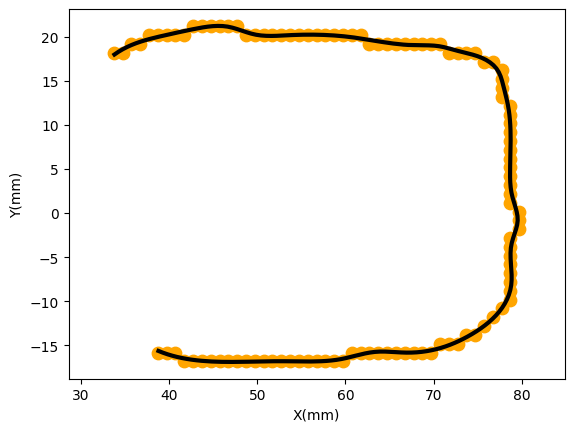

In [16]:
plt.plot(spline_points[:, 0], spline_points[:, 1], color='black', label='B-spline', lw=3)
plt.scatter(reordered_points[:, 0], reordered_points[:, 1], color='orange', s=80, label='Path Points', alpha=1)
plt.axis('equal')
plt.xlabel('X(mm)')
plt.ylabel('Y(mm)')
plt.show()

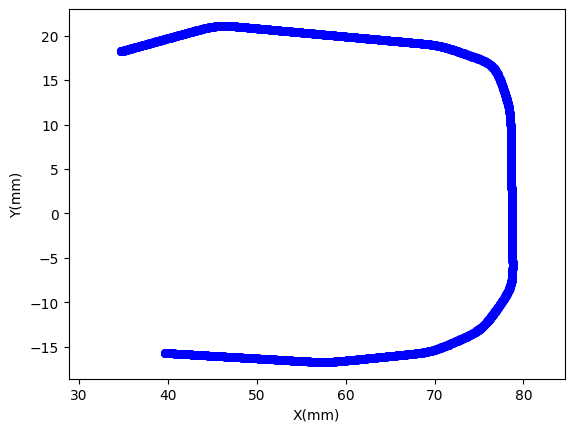

In [17]:
sampled_points = smooth_path(sampled_points, 2, 15)

plt.scatter(sampled_points[:, 0], sampled_points[:, 1], color='blue', alpha=1, s=30)
plt.axis('equal')
plt.xlabel('X(mm)')
plt.ylabel('Y(mm)')
plt.show()

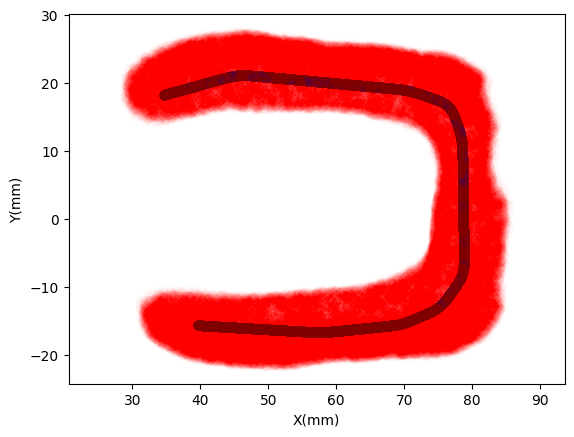

In [18]:
plt.scatter(sampled_points[:, 0], sampled_points[:, 1], color='blue')
plt.scatter(weld_bead[:, 0], weld_bead[:, 1], c = 'red', alpha = 0.007, label = 'Weld bead')

plt.axis('equal')
plt.xlabel('X(mm)')
plt.ylabel('Y(mm)')
plt.show()

# Workpiece surface fitting + projecting the 2D path points into 3D path points

In [19]:
from scipy.spatial import Delaunay
from scipy.interpolate import griddata

time13 = time.time()

points_3D = np.column_stack((X.ravel(), Y.ravel(), Z.ravel()))

# Build the Delaunay triangulation
tri = Delaunay(points_3D[:, :2])

# Compute the projected points' height on the surface
# z_projected = griddata(work_piece[:, :2], work_piece[:, 2], sampled_points, method='linear')   #linear
z_projected  = spline.ev(sampled_points[:, 0], sampled_points[:, 1])

path_3D = []
for i in range(len(sampled_points)):
    path_3D.append([sampled_points[i, 0], sampled_points[i, 1], z_projected[i]])

time14 = time.time()
t7 = np.round((time14 - time13), 4)

print("Path point projection time: ", t7, "s")

Path point projection time:  1.4666 s


In [20]:
def flip_point_cloud(point_cloud, axis='x'):
    if axis == 'x':
        rotation_matrix = np.array([[1,  0,  0],
                                    [0, -1,  0],
                                    [0,  0, -1]])
    elif axis == 'y':
        rotation_matrix = np.array([[-1,  0,  0],
                                    [0,  1,  0],
                                    [0,  0, -1]])
    elif axis == 'z':
        rotation_matrix = np.array([[-1,  0,  0],
                                    [0, -1,  0],
                                    [0,  0,  1]])
    pcd = o3d.geometry.PointCloud()
    pcd.points = o3d.utility.Vector3dVector(point_cloud)
    pcd.rotate(rotation_matrix)
    return np.asarray(pcd.points)

rotation_matrix = np.array([[1,  0,  0],
                            [0, -1,  0],
                            [0,  0, -1]])

# Normal vector computation

In [21]:
time15 = time.time()

path_3D = np.array(path_3D)

def compute_normal(tri, points):
    normals = []
    for point in points:
        # Find the triangle containing the point
        simplex = tri.find_simplex(point[:2])
        if simplex == -1:
            normals.append([0, 0, 1])  # Default normal if point is outside the convex hull
            continue
        vertices = tri.simplices[simplex]
        p0, p1, p2 = points_3D[vertices]
        # Compute the normal vector of the triangle
        v1 = p1 - p0
        v2 = p2 - p0
        normal = np.cross(v1, v2)
        normal = normal / np.linalg.norm(normal)  # Normalize the vector
        normals.append(normal)
    return np.array(normals)

normals = compute_normal(tri, path_3D)
normals = (rotation_matrix @ normals.T).T
time16 = time.time()
t8 = np.round((time16 - time15), 4)

print("Normal vector computation time: ", t8, "s")

Normal vector computation time:  0.9023 s


# Camera-to-robot offset (provisional, not a real calibration)

The project's real eye-to-hand calibration (`old/Eye-to-Hand_Calibration(SVD+ICP).ipynb`) needs the physical robot to touch known points while the camera watches -- not available right now. Standing in for it here: a fixed rigid transform (`CAMERA_OFFSET_MM` translation + `CAMERA_OFFSET_EULER_DEG` rotation), physically matched by placing/orienting the table/workpiece where the offset says it should be, instead of solving for an unknown transform. See the comment in the cell below for how to set the values.

**To experiment with different offsets/rotations:** edit the values and re-run just this cell, then re-run everything below down to "Generate Syntec/Leantec robot program" -- all of that is cheap (no segmentation or path-planning), so the whole loop is fast. The cell freezes the pre-offset cloud the first time it runs, so re-running it repeatedly never compounds transforms.

In [22]:
# PROVISIONAL hand-eye offset -- not a real eye-to-hand calibration.
#
# We can't run the proper SVD+ICP calibration (old/Eye-to-Hand_Calibration(SVD+ICP).ipynb)
# right now -- that needs the physical robot to touch known points while the camera
# watches. Workaround instead of solving for an unknown transform: FIX a simple rigid
# transform (translation + rotation), then position the camera/table in real life to
# match it.
#
# CAMERA_OFFSET_MM = where the scanner's (0,0,0) sits, measured/placed in the robot's
# USERCOR P0 frame.
# CAMERA_OFFSET_EULER_DEG = rotation from the scanner's X/Y/Z axes to the robot's
# USERCOR P0 (world) frame axes, as Euler angles (CAMERA_OFFSET_EULER_CONVENTION order).
# Leave at [0, 0, 0] if the camera is mounted axis-aligned with the robot base.
#
# Placeholder values below -- measure your real setup (tape measure / jog the robot to
# the scanner's origin point and read its position and orientation) and replace them,
# then physically position the table so the workpiece actually ends up there.
#
# To experiment: edit CAMERA_OFFSET_MM / CAMERA_OFFSET_EULER_DEG and just re-run this
# cell (then re-run the cells below down to "Generate Syntec/Leantec robot program" --
# they're all cheap, no need to redo segmentation/path-planning). Safe to re-run any
# number of times: the un-transformed cloud is frozen into *_camera_frame the first time
# this cell runs, so repeated runs always transform from that original, never from a
# previous run's already-transformed result.
CAMERA_OFFSET_MM = np.array([400.0, 0.0, 300.0])  # X, Y, Z -- PLACEHOLDER, replace with your measured/placed offset
CAMERA_OFFSET_EULER_DEG = np.array([0.0, 0.0, 0.0])  # rotation about X, Y, Z -- PLACEHOLDER, replace with your measured/placed rotation
CAMERA_OFFSET_EULER_CONVENTION = 'xyz'

#----------------------------------------------------------------------------------------------------------

from scipy.spatial.transform import Rotation as R

# Freeze the pre-offset (camera-frame) cloud on the first run only, so later re-runs of this
# cell (with different CAMERA_OFFSET_MM / CAMERA_OFFSET_EULER_DEG) always start from the same
# original data instead of re-transforming an already-transformed path_3D/work_piece/normals.
if 'path_3D_camera_frame' not in globals():
    combined_point_cloud = np.vstack([path_3D, work_piece])
    combined_point_cloud = flip_point_cloud(combined_point_cloud, axis='x')  # the reconstruction rotated it 180 deg about X, undo that here
    path_3D_camera_frame = combined_point_cloud[:len(path_3D)]
    work_piece_camera_frame = combined_point_cloud[len(path_3D):]
    normals_camera_frame = np.array(normals)

# Apply the hand-eye rotation, then the translation (camera frame -> robot USERCOR P0 frame)
camera_rotation = R.from_euler(CAMERA_OFFSET_EULER_CONVENTION, CAMERA_OFFSET_EULER_DEG, degrees=True)
combined_point_cloud = np.vstack([path_3D_camera_frame, work_piece_camera_frame])
transformed_point_cloud = camera_rotation.apply(combined_point_cloud) + CAMERA_OFFSET_MM

# Split back into path_3D and work_piece
num_path_3D_points = len(path_3D_camera_frame)
path_3D = transformed_point_cloud[:num_path_3D_points]
work_piece = transformed_point_cloud[num_path_3D_points:]

# Normals are directions, not positions -- rotate them (same rotation as above), don't translate.
normals = camera_rotation.apply(normals_camera_frame)
#----------------------------------------------------------------------------------------------------------

path_pcd = o3d.geometry.PointCloud()
path_pcd.points = o3d.utility.Vector3dVector(path_3D)

work_piece_pcd = o3d.geometry.PointCloud()
work_piece_pcd.points = o3d.utility.Vector3dVector(work_piece)

normals_pcd = o3d.geometry.PointCloud()
normals_pcd.points = o3d.utility.Vector3dVector(path_3D)
normals_pcd.normals = o3d.utility.Vector3dVector(normals)

coordinate_frame = o3d.geometry.TriangleMesh.create_coordinate_frame(size=20)

# Visualize
# o3d.visualization.draw_geometries([path_pcd, work_piece_pcd, normals_pcd, coordinate_frame])

# Multi-layer grinding path offset

In [23]:
time17 = time.time()

# Gaussian path-smoothing function
def smooth_path_gaussian(path_3D, sigma):
    smoothed_path = np.zeros_like(path_3D)
    for i in range(3):
        smoothed_path[:, i] = gaussian_filter1d(path_3D[:, i], sigma=sigma)
    return smoothed_path

def offset_point_cloud(work_piece, path_3D, num_layers, offset_distance, normals, sigma=1):
    normals = np.asarray(normals)  # normal vectors of the projected points

    offset_layers = []                 # each layer's offset path points
    offset_point_clouds = []
    for i in range(1, num_layers + 1):
        offset = path_3D + normals * (offset_distance * i)     # offset the path points
        pcd_offset = o3d.geometry.PointCloud()
        pcd_offset.points = o3d.utility.Vector3dVector(offset)
        pcd_offset.paint_uniform_color([1, 0, 0])

        offset_layers.append(offset)  # save this layer's offset path points
        offset_point_clouds.append(pcd_offset)

    # Blocking Open3D preview disabled -- see the single visualization cell at the end of the notebook.

    offset_np = [np.asarray(pcd.points) for pcd in offset_point_clouds]
    return offset_np, normals, offset_layers

def smooth_normals(normals, sigma=5):
    smoothed_normals = np.zeros_like(normals)

    for i in range(3):  # smooth the x, y, z components separately
        smoothed_normals[:, i] = gaussian_filter1d(normals[:, i], sigma=sigma, mode='reflect')
    norm = np.linalg.norm(smoothed_normals, axis=1, keepdims=True)
    norm[norm == 0] = 1  # avoid dividing by zero
    smoothed_normals /= norm  # renormalize the smoothed normals
    return smoothed_normals

normals = smooth_normals(normals, sigma=0.75)
normals = smooth_normals(normals, sigma=0.75)
normals = smooth_normals(normals, sigma=0.75)

num_layers = 6       # number of multi-pass grinding layers to offset (total passes - 1)
offset_distance = min_distance/num_layers

time4 = time.time()

offset_point_clouds, normals, offset_layers = offset_point_cloud(work_piece, path_3D, num_layers, offset_distance, normals)

for i, layer_points in enumerate(offset_layers):
    df = pd.DataFrame(layer_points, columns=['x', 'y', 'z'])
    df = df.iloc[1:].reset_index(drop=True)
    globals()[f'df_path{i + 1}'] = df

time18 = time.time()
t9 = np.round((time18 - time17), 4)

print("Multi-layer grinding path offset time: ", t9, "s")

Multi-layer grinding path offset time:  0.006 s


# Path movement vectors

In [24]:
time19 = time.time()

lines = [[i, i + 1] for i in range(len(path_3D) - 1)]
colors = [[1, 0, 0] for _ in range(len(lines))]

# Compute the vector for each connecting line
vectors = []
for i in range(len(path_3D) - 1):
    start_point = path_3D[i]
    end_point = path_3D[i + 1]
    vector = end_point - start_point
    vectors.append(vector)

pcd = o3d.geometry.PointCloud()
pcd.points = o3d.utility.Vector3dVector(path_3D)

line_set = o3d.geometry.LineSet(
    points=o3d.utility.Vector3dVector(path_3D),
    lines=o3d.utility.Vector2iVector(lines),
)
line_set.colors = o3d.utility.Vector3dVector(colors)

# Pose (Euler angle) computation

In [25]:
import pandas as pd
from scipy.spatial.transform import Rotation as R

path_3D = path_3D[1:]  # drop the first path point so every tangent vector has a matching point
normals = -1*normals[1:]
vectors = np.array(vectors)

EULER_CONVENTION = 'xyz'  # UNVERIFIED -- confirm against the pendant on one real point before trusting this

def calculate_euler_angles_with_non_orthogonal_normals(path_3D, normals, t_vectors):
    euler_angles = []
    for t_vector, normal in zip(t_vectors, normals):

        # Step 1: Normalize the tangent vector
        t_vector = t_vector / np.linalg.norm(t_vector)

        # Step 2: Make the normal orthogonal to the tangent via Gram-Schmidt
        normal = normal - np.dot(normal, t_vector) * t_vector
        normal = normal / np.linalg.norm(normal)

        # Step 3: Cross the normal and tangent to get the y-axis (binormal)
        y_axis = np.cross(normal, t_vector)
        y_axis = y_axis / np.linalg.norm(y_axis)

        # Step 4: Express the pose frame as a rotation matrix
        rotation_matrix = np.vstack((t_vector, y_axis, normal)).T  # 3x3 rotation matrix

        # Step 5: Convert the rotation matrix directly to Euler angles
        euler_angles.append(R.from_matrix(rotation_matrix).as_euler(EULER_CONVENTION, degrees=True))
    return np.array(euler_angles)

euler_angles = calculate_euler_angles_with_non_orthogonal_normals(path_3D, normals, vectors)

time20 = time.time()
t10 = np.round((time20 - time19), 4)
print("Robot arm pose computation time: ", t10, "s")

time21 = time.time()

df_path0 = pd.DataFrame(path_3D, columns=['x', 'y', 'z'])
df_normals = pd.DataFrame(normals, columns=['i', 'j', 'k'])
df_euler = pd.DataFrame(euler_angles, columns=['a', 'b', 'c'])
df_0 = pd.concat([df_path0, df_normals, df_euler], axis=1)
df_0.iloc[:, :3] += [0, 0, 0]         #[450, 0, 450]
df_0 = df_0.round(4)

for n, offset_layer in enumerate(offset_layers, start=1):
    df_path_n = pd.DataFrame(offset_layer, columns=['x', 'y', 'z'])
    df_n = pd.concat([df_path_n, df_normals, df_euler], axis=1)
    df_n = df_n.iloc[:-1]
    df_n = df_n.round(4)
    df_n.iloc[:, :3] += [0, 0, 0]     #[450, 0, 450]
    globals()[f'df_{n}'] = df_n

time22 = time.time()

Robot arm pose computation time:  0.5671 s


# Save trajectory

Replaces the original notebook's TCP/RTCP RAPID `.mod` file export cells -- final conversion to robot-specific language isn't handled here yet. Saves every layer (`df_0` = the grinding-line layer, `df_1..df_num_layers` = the offset passes) to `outputs/`, columns `x, y, z, i, j, k, a, b, c` (position, normal, Euler angles), still in the robot frame from the eye-to-hand transform above.

In [26]:
import os
os.makedirs('outputs', exist_ok=True)

DEBUG_FIRST_LAYER_ONLY = True  # True -- only export layer 0 (the grinding line), skip the num_layers offset passes; handy for debugging

all_layers = [df_0] + [globals()[f'df_{n}'] for n in range(1, num_layers + 1)]
if DEBUG_FIRST_LAYER_ONLY:
    all_layers = all_layers[:1]
trajectory = pd.concat(all_layers, keys=range(len(all_layers)), names=['layer', 'idx']).reset_index()
trajectory = trajectory.drop(columns=['idx'])

out_path = 'outputs/trajectory.csv'
trajectory.to_csv(out_path, index=False)
exported_offset_passes = 0 if DEBUG_FIRST_LAYER_ONLY else num_layers
print(f"Wrote {out_path}: {len(trajectory)} pose points across {len(all_layers)} layers (1 grinding line + {exported_offset_passes} offset passes)")
trajectory.head()

Wrote outputs/trajectory.csv: 1414 pose points across 1 layers (1 grinding line + 0 offset passes)


,layer,x,y,z,i,j,k,a,b,c
0,0,439.7071,22.7673,472.3170,0.1117,-0.6212,0.7756,38.8126,5.4821,3.4105
1,0,439.7155,22.7678,472.3162,0.1116,-0.6212,0.7756,38.8127,5.4819,3.4105
2,0,439.7280,22.7685,472.3150,0.1114,-0.6212,0.7756,38.8128,5.4816,3.4105
3,0,439.7447,22.7695,472.3134,0.1113,-0.6213,0.7757,38.8129,5.4812,3.4105
4,0,439.7654,22.7708,472.3114,0.1113,-0.6213,0.7757,38.8129,5.4807,3.4105


# Generate Syntec/Leantec robot program

Converts `trajectory` into `MOVJ X.. Y.. Z.. A.. B.. C.. P.. Q..;` lines, using the syntax confirmed against the vendor's own example program (Cartesian target, controller computes IK itself -- see `outputs/leantec_example_program.txt`).

**Orientation convention is unverified.** `a, b, c` are Euler angles computed directly from each point's pose frame (see the trajectory cell above), using `EULER_CONVENTION` -- axis order and intrinsic/extrinsic convention aren't confirmed against the controller's docs, `'xyz'` extrinsic degrees is used as a common default. **Before trusting orientation on real hardware: jog to one output point manually and compare A/B/C against what the pendant shows**, adjust `EULER_CONVENTION` (in the trajectory cell above) if it doesn't match.

Also subsamples -- `trajectory` has thousands of points per layer (dense enough for the geometry fit, far denser than a real program needs), so this keeps every `SUBSAMPLE_STRIDE`th point (always including each layer's first/last point).

In [27]:
# --- tune these ---
MAX_POINTS_PER_LAYER = 150  # subsample each layer down to at most this many points
FEED_JOINT_PCT = 20         # FJ.. -- joint move speed, percent
USER_FRAME = 0               # P..
TOOL_FRAME = 0               # Q..

def subsample_layer(df, max_points):
    n = len(df)
    if n <= max_points:
        return df
    stride = max(1, n // max_points)
    idx = list(range(0, n, stride))
    if idx[-1] != n - 1:
        idx.append(n - 1)  # always keep the last point
    return df.iloc[idx]

lines = []
lines.append(f"USERCOR P{USER_FRAME}; // world coordinate system {USER_FRAME}")
lines.append(f"TOOLCOR P{TOOL_FRAME}; // tool/flange coordinate system {TOOL_FRAME}")
lines.append(f"FJ{FEED_JOINT_PCT}.; // joint move speed {FEED_JOINT_PCT}%")
lines.append("")

total_points = 0
for layer_id, layer_df in trajectory.groupby('layer'):
    sub = subsample_layer(layer_df.reset_index(drop=True), MAX_POINTS_PER_LAYER)
    lines.append(f"// --- layer {layer_id}: {len(sub)} / {len(layer_df)} points ---")
    for _, row in sub.iterrows():
        lines.append(
            f"MOVJ X{row['x']:.3f} Y{row['y']:.3f} Z{row['z']:.3f} "
            f"A{row['a']:.3f} B{row['b']:.3f} C{row['c']:.3f} P{USER_FRAME} Q{TOOL_FRAME};"
        )
    total_points += len(sub)

lines.append("M99;")

out_path = "outputs/leantec_program.txt"
with open(out_path, "w") as f:
    f.write("\n".join(lines) + "\n")

print(f"Wrote {out_path}: {total_points} points across {trajectory['layer'].nunique()} layers "
      f"(from {len(trajectory)} points before subsampling)")

Wrote outputs/leantec_program.txt: 158 points across 1 layers (from 1414 points before subsampling)


# Timing summary

In [28]:
print("Weld bead recognition: ", t1, "s")
print("Voxel filtering: ", t2, "s")
print("Weld bead height computation: ", t3, "s")
print("Point cloud rasterization: ", t4, "s")
print("Path point ordering: ", t5, "s")
print("Path fitting and simplification: ", t6, "s")
print("Path point projection: ", t7, "s")
print("Normal vector computation: ", t8, "s")
print("Multi-layer grinding path offset: ", t9, "s")
print("Robot arm pose computation: ", t10, "s")

Weld bead recognition:  41.5797 s
Voxel filtering:  22.714 s
Weld bead height computation:  58.0073 s
Point cloud rasterization:  0.9559 s
Path point ordering:  2.1613 s
Path fitting and simplification:  0.5523 s
Path point projection:  1.4666 s
Normal vector computation:  0.9023 s
Multi-layer grinding path offset:  0.006 s
Robot arm pose computation:  0.5671 s


# Visualize robot poses

The one interactive Open3D window in this notebook (all the others above are disabled). Shows the workpiece surface (gray), the grinding-line path points (red), the world/robot origin (USERCOR P0, `[0, 0, 0]` -- the frame `CAMERA_OFFSET_MM`/`CAMERA_OFFSET_EULER_DEG` transformed everything into, drawn larger than the pose frames), and a coordinate frame at each pose: **red = X (path tangent)**, **green = Y (binormal)**, **blue = Z (surface normal / tool approach direction)** -- built straight from `df_0`'s `x, y, z, a, b, c` columns, so it's a direct check of what actually got written to `outputs/leantec_program.txt`. Subsampled to `POSE_VIZ_MAX_POSES` frames so they stay legible; close the window to continue.

In [29]:
POSE_VIZ_MAX_POSES = 40  # subsample so the frames stay legible

pose_df = subsample_layer(df_0.reset_index(drop=True), POSE_VIZ_MAX_POSES)

work_piece_pcd_viz = o3d.geometry.PointCloud()
work_piece_pcd_viz.points = o3d.utility.Vector3dVector(work_piece)
work_piece_pcd_viz.paint_uniform_color([0.7, 0.7, 0.7])

path_pcd_viz = o3d.geometry.PointCloud()
path_pcd_viz.points = o3d.utility.Vector3dVector(pose_df[['x', 'y', 'z']].to_numpy())
path_pcd_viz.paint_uniform_color([1, 0, 0])

# Scale the coordinate frames relative to the workpiece so they're visible but not overwhelming
frame_size = np.linalg.norm(work_piece.max(axis=0) - work_piece.min(axis=0)) * 0.03

# World/robot origin (USERCOR P0, [0, 0, 0]) that CAMERA_OFFSET_MM/CAMERA_OFFSET_EULER_DEG
# transformed everything into -- drawn larger than the pose frames so it stands out
origin_frame = o3d.geometry.TriangleMesh.create_coordinate_frame(size=frame_size * 3, origin=[0, 0, 0])

geometries = [work_piece_pcd_viz, path_pcd_viz, origin_frame]
for _, row in pose_df.iterrows():
    frame = o3d.geometry.TriangleMesh.create_coordinate_frame(size=frame_size)
    rot = R.from_euler(EULER_CONVENTION, [row['a'], row['b'], row['c']], degrees=True).as_matrix()
    frame.rotate(rot, center=(0, 0, 0))
    frame.translate([row['x'], row['y'], row['z']])
    geometries.append(frame)

o3d.visualization.draw_geometries(geometries, window_name="Robot poses along grinding path",
                                  width=1000, height=700, left=50, top=50)